In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv("master_dataset.csv", parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

df['product_category_name_english'].fillna('Unknown', inplace=True)
df.dropna(subset=['review_score', 'payment_value'], inplace=True)

print(f"Dataset ready: {df.shape}")

Dataset ready: (114166, 31)


In [7]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df.groupby('order_month')['payment_value'].sum().reset_index()
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

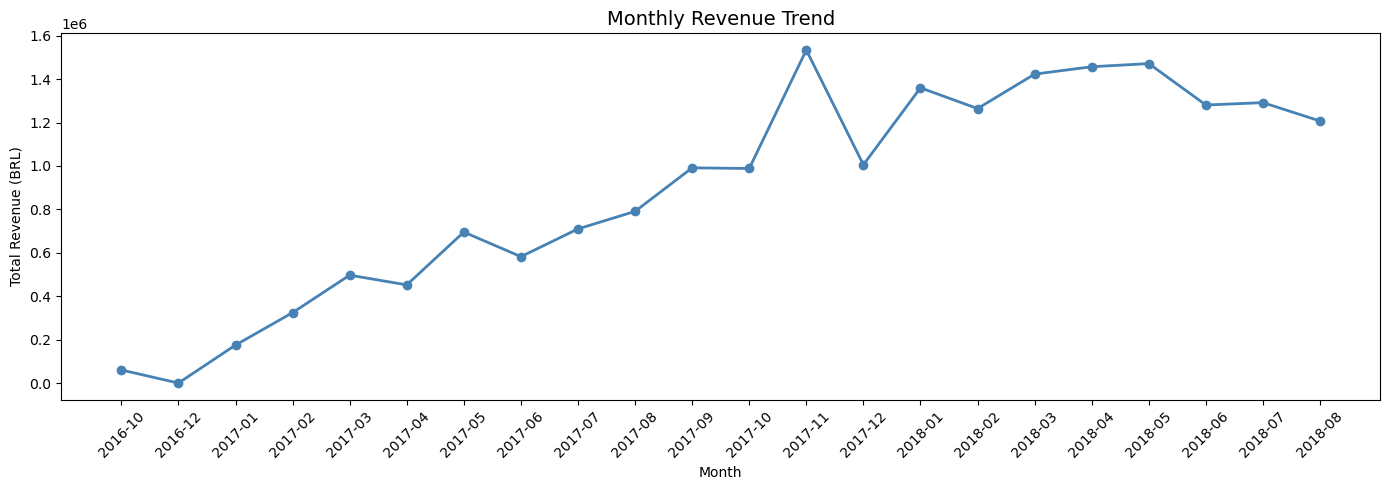

In [28]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['order_month'], 
         monthly_revenue['payment_value'], 
         marker='o', color='steelblue', linewidth=2)

plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('Visuals/monthly_revenue.png', dpi=150)
plt.show()

**Insight**

Revenue showed consistent growth from late 2016 through 2017, peaking in November 2017 at approximately 1.5M BRL, likely driven by Black Friday promotions. Post-peak, revenue stabilized between 1.2M–1.4M BRL throughout 2018, indicating a maturing but healthy business.

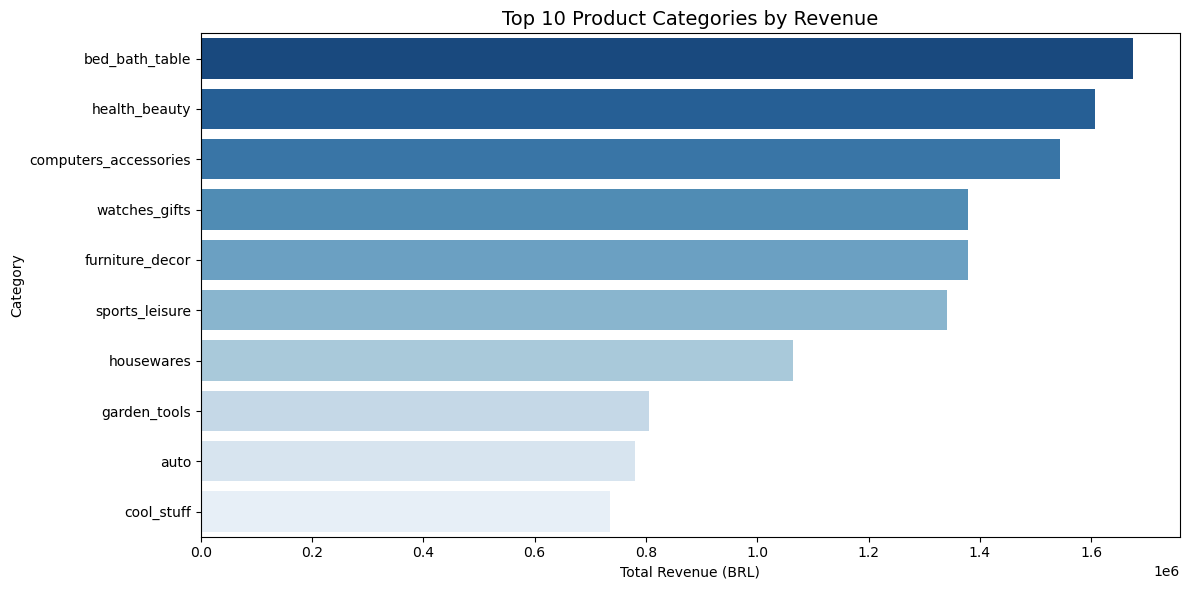

In [29]:
top_categories = df.groupby('product_category_name_english')['payment_value']\
                   .sum()\
                   .sort_values(ascending=False)\
                   .head(10)\
                   .reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, 
            x='payment_value', 
            y='product_category_name_english',
            palette='Blues_r')

plt.title('Top 10 Product Categories by Revenue', fontsize=14)
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('Visuals/top_categories.png', dpi=150)
plt.show()

**Insight**

Home and lifestyle categories dominate revenue, with Bed/Bath/Table leading at 1.65M BRL, followed by Health & Beauty and Computers/Accessories. This suggests Brazilian consumers prioritize home improvement and personal care purchases on this platform.

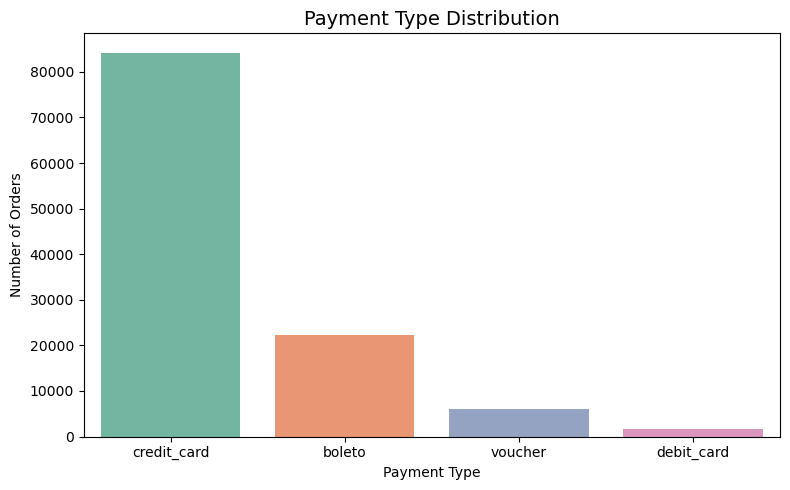

In [30]:
payment_dist = df['payment_type'].value_counts().reset_index()
payment_dist.columns = ['payment_type', 'count']

plt.figure(figsize=(8, 5))
sns.barplot(data=payment_dist,
            x='payment_type',
            y='count',
            palette='Set2')

plt.title('Payment Type Distribution', fontsize=14)
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('Visuals/payment_types.png', dpi=150)
plt.show()

**Insight**

Credit card is the overwhelmingly preferred payment method, accounting for 73% of all transactions. Boleto (local bank slip) follows at 19%. This indicates the platform must ensure seamless credit card processing as any disruption would directly impact the majority of sales.

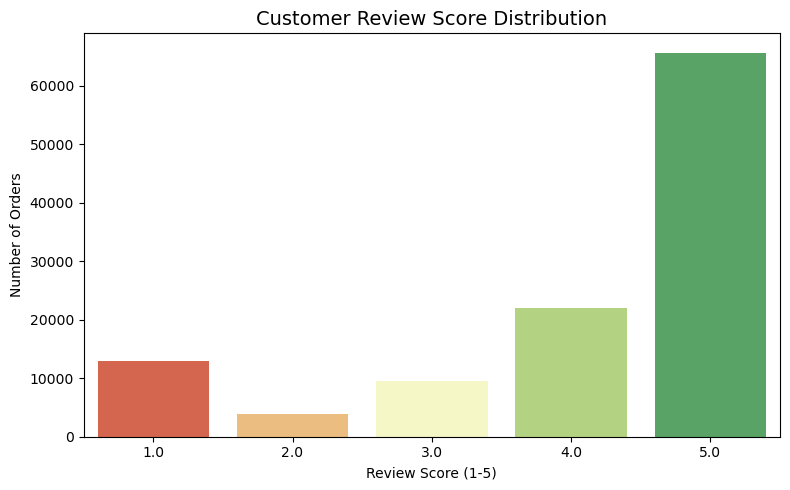

Average Review Score: 4.08


In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, 
              x='review_score',
              palette='RdYlGn')

plt.title('Customer Review Score Distribution', fontsize=14)
plt.xlabel('Review Score (1-5)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('Visuals/review_scores.png', dpi=150)
plt.show()

print(f"Average Review Score: {df['review_score'].mean():.2f}")

**Insight**

Customer satisfaction is generally positive with an average score of 4.08 out of 5. Approximately 57% of customers gave 5-star ratings. However, 13,000 customers gave 1-star reviews, representing a significant churn risk that requires immediate attention.

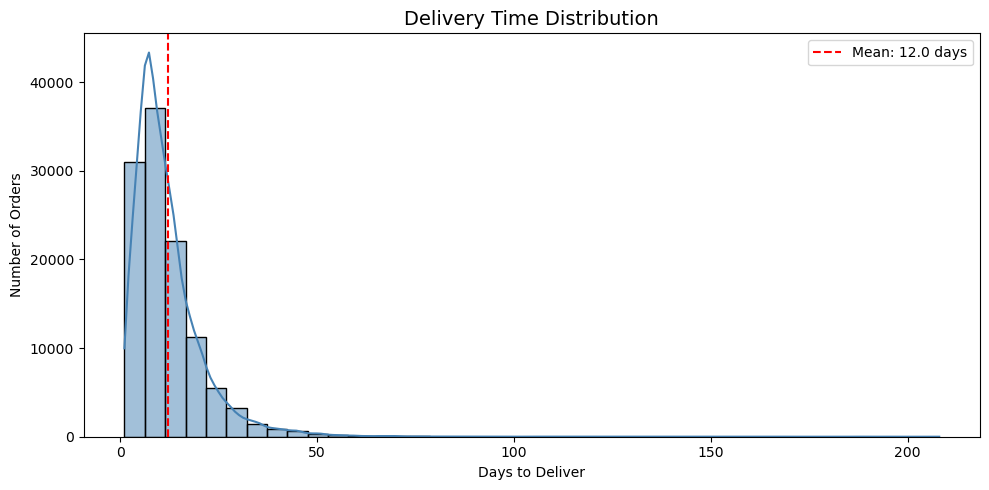

Average Delivery: 12.0 days
Median Delivery : 10.0 days
Max Delivery    : 208 days


In [32]:
df['delivery_days'] = (df['order_delivered_customer_date'] - 
                       df['order_purchase_timestamp']).dt.days

df_delivery = df[df['delivery_days'] > 0].copy()

plt.figure(figsize=(10, 5))
sns.histplot(df_delivery['delivery_days'], 
             bins=40, 
             color='steelblue',
             kde=True)

plt.title('Delivery Time Distribution', fontsize=14)
plt.xlabel('Days to Deliver')
plt.ylabel('Number of Orders')
plt.axvline(df_delivery['delivery_days'].mean(), 
            color='red', 
            linestyle='--', 
            label=f"Mean: {df_delivery['delivery_days'].mean():.1f} days")
plt.legend()
plt.tight_layout()
plt.savefig('Visuals/delivery_time.png', dpi=150)
plt.show()

print(f"Average Delivery: {df_delivery['delivery_days'].mean():.1f} days")
print(f"Median Delivery : {df_delivery['delivery_days'].median():.1f} days")
print(f"Max Delivery    : {df_delivery['delivery_days'].max()} days")

**Insight**

Most orders are delivered within 10–15 days, with a median of 10 days. However, extreme outliers exist with a maximum delivery time of 208 days, suggesting serious logistics failures for a small subset of orders. These late deliveries are likely the primary driver of 1-star reviews.

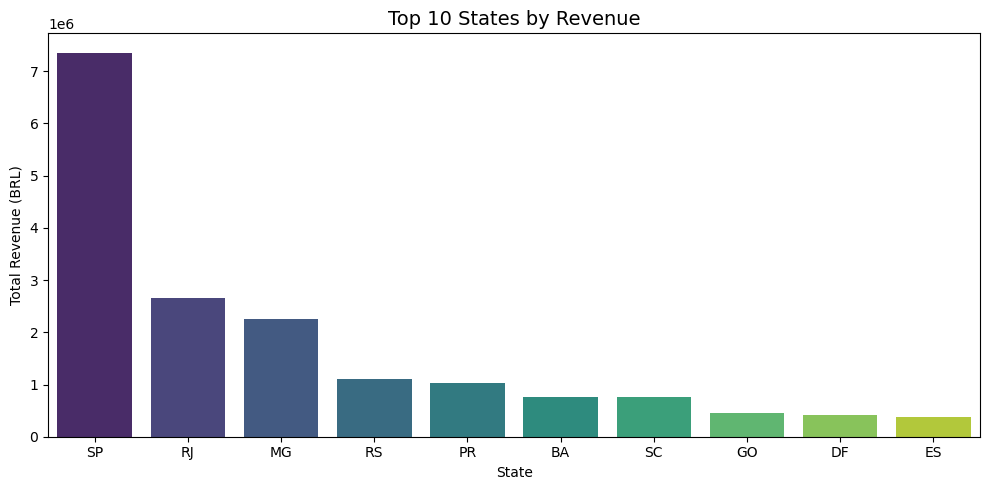

In [33]:
state_revenue = df.groupby('customer_state')['payment_value']\
                  .sum()\
                  .sort_values(ascending=False)\
                  .head(10)\
                  .reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=state_revenue,
            x='customer_state',
            y='payment_value',
            palette='viridis')

plt.title('Top 10 States by Revenue', fontsize=14)
plt.xlabel('State')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('Visuals/state_revenue.png', dpi=150)
plt.show()

**Insight**

Sao Paulo alone generates ~7.3M BRL — roughly 3x more than second-place Rio de Janeiro. SP is clearly the business hub. Top 3 states contribute majority of total revenue — classic Pareto effect in geographic distribution.

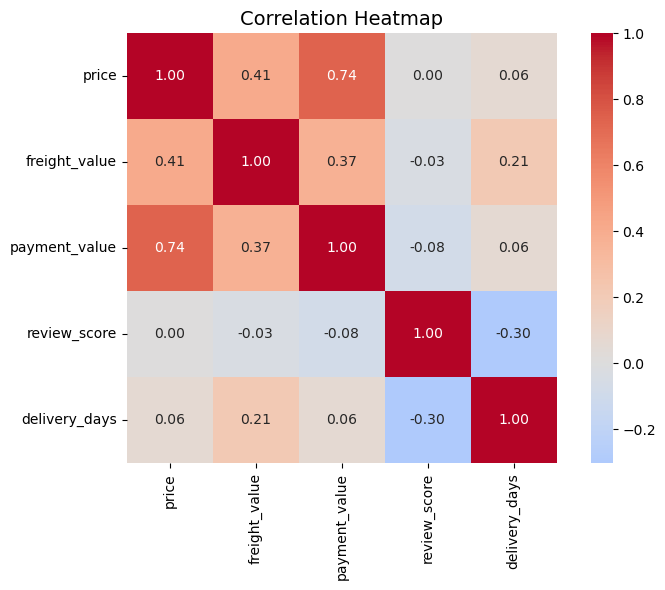

In [34]:
corr_cols = ['price', 'freight_value', 
             'payment_value', 'review_score', 
             'delivery_days']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('Visuals/correlation_heatmap.png', dpi=150)
plt.show()

**Insight**

The most actionable finding is the -0.30 negative correlation between delivery days and review score — confirming that longer delivery times directly lead to lower customer satisfaction. Price shows no meaningful correlation with review scores (0.00), proving that customers judge experience over cost.